# 🔧 다이캐스팅 불량 예측 프로젝트 (VSCode)
## Die-Casting Quality Prediction Pipeline (Production-Grade)

> **목표**: 공정(Process) + 센서(Sensor) 데이터를 활용하여 이진 분류 (양품 / 불량) 모델을 구축하고,  
> 불량 발생의 주요 원인 변수를 분석하여 공정 최적화 인사이트를 도출한다.

---

**파이프라인 구성**

| 단계 | 내용 |
|------|------|
| 0 | 패키지 설치 (pip) & 한글 폰트 자동 설정 |
| 1 | 라이브러리 & 데이터 로드 |
| 2 | 데이터 기본 파악 |
| 3 | EDA (탐색적 데이터 분석) |
| 4 | 데이터 전처리 |
| 5 | 베이스라인 모델 (LR / RF / GB) |
| **6** | **SMOTE 클래스 불균형 보정** |
| **7** | **XGBoost 모델 학습 & 튜닝** |
| **8** | **Threshold 최적화** |
| **9** | **SHAP 분석 (전역 + 개별 해석)** |
| **10** | **최종 모델 비교 & 결론** |


**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: 필요 패키지 pip 설치 & 크로스플랫폼 한글 폰트 자동 설정
- **왜**: VSCode/로컬 Jupyter 환경에서는 Colab과 달리 패키지를 직접 설치해야 하고, 한글 폰트도 OS에 맞게 자동 선택해야 함.
- **어떻게**: pip install로 xgboost/imbalanced-learn/shap 설치 후, 설치된 폰트 목록을 검색해 OS별 최적 한글 폰트를 자동 선택.
- **VSCode 한글 폰트**: NanumGothic을 사용하려면 [나눔글꼴 다운로드](https://hangeul.naver.com/font) 후 시스템에 설치하거나, `set_korean_font(nanum_path='경로/NanumGothic.ttf')` 처럼 경로를 직접 지정해야 함.


In [2]:
# ── [환경 설정] 패키지 설치 & 크로스플랫폼 한글 폰트 설정 ────────────────────
# VSCode / Jupyter 환경에서 필요한 패키지를 pip으로 설치.
# 이미 설치된 환경이라면 이 셀은 빠르게 통과됨.

import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip_install('xgboost', 'imbalanced-learn', 'shap')

# ── 크로스플랫폼 한글 폰트 자동 설정 ────────────────────────────────────────
import os, platform
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def set_korean_font(nanum_path=None):
    """NanumGothic 우선, 없으면 OS 기본 한글 폰트로 fallback."""
    available = {f.name for f in fm.fontManager.ttflist}

    if 'NanumGothic' in available:
        plt.rcParams['font.family'] = 'NanumGothic'
    elif nanum_path and os.path.exists(nanum_path):
        fm.fontManager.addfont(nanum_path)
        plt.rcParams['font.family'] = fm.FontProperties(fname=nanum_path).get_name()
    else:
        sysname = platform.system()
        if sysname == 'Windows':
            # Windows 기본 한글 폰트 탐색
            for cand in ['Malgun Gothic', 'NanumGothic']:
                if cand in available:
                    plt.rcParams['font.family'] = cand
                    break
            else:
                # Windows 폰트 폴더에서 직접 탐색
                win_nanum = r'C:\Windows\Fonts\NanumGothic.ttf'
                if os.path.exists(win_nanum):
                    fm.fontManager.addfont(win_nanum)
                    plt.rcParams['font.family'] = 'NanumGothic'
        elif sysname == 'Darwin':
            for cand in ['AppleGothic', 'NanumGothic', 'Apple SD Gothic Neo']:
                if cand in available:
                    plt.rcParams['font.family'] = cand
                    break
        else:  # Linux
            for cand in ['NanumGothic', 'NanumBarunGothic', 'Noto Sans CJK KR', 'DejaVu Sans']:
                if cand in available:
                    plt.rcParams['font.family'] = cand
                    break

    plt.rcParams['axes.unicode_minus'] = False
    print(f"✅ 한글 폰트 설정 완료: {plt.rcParams['font.family']}")

# ✅ NanumGothic이 없다면 아래 경로를 본인 PC에 맞게 수정하세요.
# 예시(Windows): set_korean_font(nanum_path=r'C:\Windows\Fonts\NanumGothic.ttf')
set_korean_font()
plt.rcParams['figure.figsize'] = (10, 5)
print('✅ 환경 설정 완료')


✅ 한글 폰트 설정 완료: ['Malgun Gothic']
✅ 환경 설정 완료


## 1️⃣ 라이브러리 & 데이터 로드

**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: 분석에 필요한 기본 라이브러리 불러오기
- **왜**: 데이터 처리(NumPy/Pandas), 시각화(Matplotlib/Seaborn), 경고 관리 등을 위해.
- **어떻게**: 필요한 패키지를 import 하고, 표시 옵션/시각화 기본값을 설정.


In [3]:
# ── 기본 라이브러리 ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── 시각화 설정 ──────────────────────────────────────────────
plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
PALETTE = ['#4C72B0', '#DD8452']

# 한글 폰트 설정 (Cell 0에서 정의된 set_korean_font 재적용)
set_korean_font()

# ── 사이킷런 ─────────────────────────────────────────────────
from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing     import StandardScaler
from sklearn.pipeline          import Pipeline
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model      import LogisticRegression
from sklearn.metrics           import (classification_report, confusion_matrix,
                                        roc_auc_score, roc_curve,
                                        precision_recall_curve, average_precision_score,
                                        ConfusionMatrixDisplay)
from sklearn.inspection        import permutation_importance

print('✅ 라이브러리 로드 완료')


✅ 한글 폰트 설정 완료: ['Malgun Gothic']
✅ 라이브러리 로드 완료


**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: 한글 폰트 자동 설정 함수 정의 및 적용
- **왜**: 노트북 어디에서 그래프를 그려도 한글이 안정적으로 표시되도록 설정을 한 곳에서 통일하려고.
- **어떻게**: 설치된 폰트 목록을 확인해 NanumGothic을 우선 선택하고, 없으면 OS별 대체 폰트를 선택.


In [4]:
# ── [폰트/시각화] 한글 폰트 재적용 ────────────────────────────────────────
# set_korean_font() 함수는 Cell 0에서 정의되었습니다.
# 이 셀은 그래프 기본 크기 설정을 포함한 재적용 셀입니다.
set_korean_font()
plt.rcParams['figure.figsize'] = (10, 5)
print('✅ 한글 폰트 & 시각화 설정 재적용 완료')


✅ 한글 폰트 설정 완료: ['Malgun Gothic']
✅ 한글 폰트 & 시각화 설정 재적용 완료


**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: 분석에 필요한 기본 라이브러리 불러오기
- **왜**: 데이터 처리(NumPy/Pandas), 시각화(Matplotlib/Seaborn), 경고 관리 등을 위해 필수.
- **어떻게**: 필요한 패키지를 import 하고, 표시 옵션/시각화 기본값을 설정.


In [5]:
# ── [1] 라이브러리 import (중복 설치 셀 정리) ─────────────────────────────
# 위 [0] 셀에서 패키지 설치를 이미 했다면, 여기서는 import만 진행.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)

**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: CSV 데이터 로드 및 헤더(컬럼명) 자동 복구
- **왜**: 원본 파일이 2줄 헤더/중복 헤더 형태라 그대로 읽으면 `Process.1` 같은 깨진 컬럼명이 생길 수 있음.
- **어떻게**: 2줄 헤더로 먼저 읽어 결합하고, 실패 시 다른 방식으로 재시도해 컬럼명을 정리함.


In [6]:
# ── 데이터 로드 (헤더 자동 복구) ─────────────────────────────────────────────
DATA_PATH = 'DieCasting_Quality_Raw_Data.csv'   # 같은 폴더에 위치

import pandas as pd
import numpy as np
import re

# 1) (권장) 2줄 헤더(Process/Defects)를 MultiIndex로 읽기
try:
    df_raw = pd.read_csv(DATA_PATH, header=[0, 1])
    # 각 헤더 파트의 공백을 먼저 정리한 뒤 join
    new_cols = []
    for a, b in df_raw.columns:
        a = str(a).strip()
        b = str(b).strip()
        b = re.sub(r'\s+', '_', b)   # 중간 공백 -> _
        new_cols.append(f"{a}_{b}".strip("_"))
    df_raw.columns = new_cols
except Exception:
    # 2) (fallback) 헤더가 2행이 아닐 경우(파일이 편집된 경우) 대비
    df_raw = pd.read_csv(DATA_PATH, header=1)
    df_raw.columns = [c.strip().replace(" ", "_") for c in df_raw.columns]

# 컬럼명 후처리(연속 언더스코어 제거)
df_raw.columns = [re.sub(r'_+', '_', c).strip('_') for c in df_raw.columns]

display(df_raw.head())
print("Rows:", len(df_raw), "| Cols:", df_raw.shape[1])

,Process_id,Process_Product_Type,Process_Shot,Process_Velocity_1,Process_Velocity_2,Process_Velocity_3,Process_High_Velocity,Process_Cylinder_Pressure,Process_Rapid_Rise_Time,Process_Biscuit_Thickness,Process_Clamping_Force,Process_Cycle_Time,Process_Pressure_Rise_Time,Process_Casting_Pressure,Process_Spray_Time,Process_Spray_1_Time,Process_Spray_2_Time,Sensor_Melting_Furnace_Temp,Sensor_Air_Pressure,Sensor_Air_Pressure_Min,Sensor_Air_Pressure_Max,Sensor_Coolant_Temp,Sensor_Coolant_Temp_Min,Sensor_Coolant_Temp_Max,Sensor_Coolant_Pressure,Sensor_Factory_Temp,Sensor_Factory_Temp_Min,Sensor_Factory_Temp_Max,Sensor_Factory_Humidity,Sensor_Factory_Humidity_Min,Sensor_Factory_Humidity_Max,Defects_Short_Shot_1,Defects_Bubble_1,Defects_Exfoliation_1,Defects_Blow_Hole_1,Defects_Stain_1,Defects_Dent_1,Defects_Deformation_1,Defects_Contamination_1,Defects_Impurity_1,Defects_Crack_1,Defects_Scratch_1,Defects_Buring_Mark_1,Defects_Inclusions_1,Defects_Short_Shot_2,Defects_Bubble_2,Defects_Exfoliation_2,Defects_Blow_Hole_2,Defects_Stain_2,Defects_Dent_2,Defects_Deformation_2,Defects_Contamination_2,Defects_Impurity_2,Defects_Crack_2,Defects_Scratch_2,Defects_Buring_Mark_2,Defects_Inclusions_2
0,1,1,1,0.1440,0.1700,0.1880,2.1340,214,0.0080,10,258,20.7000,0.0440,1037,7.8000,0.7000,0.8000,695.0000,6.3000,3,9,26.0000,10,50,2.7100,32.9000,18.0000,22.0000,58.4000,18.0000,22.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1002,1,2,0.1440,0.1700,0.1820,2.1240,217,0.0080,11,257,20.7000,0.0440,1052,7.8000,0.7000,0.8000,696.4000,6.3000,3,9,26.1000,10,50,2.6900,32.9000,18.0000,22.0000,58.2000,18.0000,22.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2003,1,3,0.1440,0.1700,0.1820,2.1160,214,0.0080,11,257,20.8000,0.0410,1037,7.8000,0.7000,0.8000,696.4000,6.3000,3,9,26.1000,10,50,2.6900,32.9000,18.0000,22.0000,58.2000,18.0000,22.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,3004,1,4,0.1440,0.1700,0.1820,2.1370,217,0.0080,11,257,20.7000,0.0430,1051,7.8000,0.7000,0.8000,696.4000,6.3000,3,9,26.1000,10,50,2.6900,32.9000,18.0000,22.0000,58.2000,18.0000,22.0000,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,4005,1,5,0.1440,0.1720,0.1760,2.1110,217,0.0080,12,257,20.7000,0.0420,1052,7.8000,0.7000,0.8000,697.9000,6.4000,3,9,26.1000,10,50,2.6900,32.9000,18.0000,22.0000,57.8000,18.0000,22.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Rows: 7535 | Cols: 57


## 2️⃣ 데이터 기본 파악

**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: Process/Sensor/Defect 컬럼을 자동으로 분류
- **왜**: 이후 EDA·모델링에서 어떤 컬럼을 입력 피처로 쓸지 일관되게 관리하기 위해서.
- **어떻게**: 컬럼 접두어(`Process_`, `Sensor_`)와 불량 라벨 패턴을 이용해 리스트를 만듦.


In [7]:
# ── 컬럼 분류 ────────────────────────────────────────────────
process_cols = [c for c in df_raw.columns if c.startswith('Process_') and c not in ['Process_id', 'Process_Product_Type', 'Process_Shot']]
sensor_cols  = [c for c in df_raw.columns if c.startswith('Sensor_')]
defect_cols_1 = [c for c in df_raw.columns if c.startswith('Defects_') and c.endswith('_1')]
defect_cols_2 = [c for c in df_raw.columns if c.startswith('Defects_') and c.endswith('_2')]

print('▶ 공정(Process) 변수:', len(process_cols), process_cols)
print()
print('▶ 센서(Sensor)  변수:', len(sensor_cols),  sensor_cols)
print()
print('▶ 불량(Defects) 변수(Cavity1):', len(defect_cols_1), defect_cols_1)
print()
print('▶ 불량(Defects) 변수(Cavity2):', len(defect_cols_2), defect_cols_2)


▶ 공정(Process) 변수: 14 ['Process_Velocity_1', 'Process_Velocity_2', 'Process_Velocity_3', 'Process_High_Velocity', 'Process_Cylinder_Pressure', 'Process_Rapid_Rise_Time', 'Process_Biscuit_Thickness', 'Process_Clamping_Force', 'Process_Cycle_Time', 'Process_Pressure_Rise_Time', 'Process_Casting_Pressure', 'Process_Spray_Time', 'Process_Spray_1_Time', 'Process_Spray_2_Time']

▶ 센서(Sensor)  변수: 14 ['Sensor_Melting_Furnace_Temp', 'Sensor_Air_Pressure', 'Sensor_Air_Pressure_Min', 'Sensor_Air_Pressure_Max', 'Sensor_Coolant_Temp', 'Sensor_Coolant_Temp_Min', 'Sensor_Coolant_Temp_Max', 'Sensor_Coolant_Pressure', 'Sensor_Factory_Temp', 'Sensor_Factory_Temp_Min', 'Sensor_Factory_Temp_Max', 'Sensor_Factory_Humidity', 'Sensor_Factory_Humidity_Min', 'Sensor_Factory_Humidity_Max']

▶ 불량(Defects) 변수(Cavity1): 13 ['Defects_Short_Shot_1', 'Defects_Bubble_1', 'Defects_Exfoliation_1', 'Defects_Blow_Hole_1', 'Defects_Stain_1', 'Defects_Dent_1', 'Defects_Deformation_1', 'Defects_Contamination_1', 'Defects_Imp

**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: 결측치(빈 값) 규모 확인
- **왜**: 결측치가 많으면 모델이 왜곡되거나 오류가 날 수 있어, 먼저 현황을 파악해야 함.
- **어떻게**: 컬럼별 결측치 개수 합계와 결측치가 존재하는 컬럼만 출력.


In [8]:
# ── 결측치 확인 ─────────────────────────────────────────────
missing = df_raw.isnull().sum()
print('결측치 합계:', missing.sum())
print(missing[missing > 0])


결측치 합계: 540
Sensor_Factory_Temp            90
Sensor_Factory_Temp_Min        90
Sensor_Factory_Temp_Max        90
Sensor_Factory_Humidity        90
Sensor_Factory_Humidity_Min    90
Sensor_Factory_Humidity_Max    90
dtype: int64


**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: Process/Sensor/Defect 컬럼을 자동으로 분류
- **왜**: 이후 EDA·모델링에서 어떤 컬럼을 입력 피처로 쓸지 일관되게 관리하기 위해서.
- **어떻게**: 컬럼 접두어(`Process_`, `Sensor_`)와 불량 라벨 패턴을 이용해 리스트를 만듦.


In [9]:
# ── 기초 통계 ─────────────────────────────────────────────
df_raw[process_cols + sensor_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Process_Velocity_1,7535.0000,0.1480,0.0070,0.1340,0.1420,0.1440,0.1560,0.1800
Process_Velocity_2,7535.0000,0.1690,0.0050,0.1580,0.1660,0.1680,0.1700,0.2120
Process_Velocity_3,7535.0000,0.1910,0.0120,0.1720,0.1810,0.1880,0.2020,0.2340
Process_High_Velocity,7535.0000,2.3190,0.2220,0.0000,2.1340,2.1610,2.5230,2.7440
Process_Cylinder_Pressure,7535.0000,239.6560,23.3050,107.0000,217.0000,239.0000,265.0000,266.0000
Process_Rapid_Rise_Time,7535.0000,0.0100,0.0020,0.0000,0.0080,0.0090,0.0120,0.0210
Process_Biscuit_Thickness,7535.0000,14.3100,3.2860,0.0000,11.0000,13.0000,17.0000,24.0000
Process_Clamping_Force,7535.0000,306.4330,57.2750,238.0000,255.0000,258.0000,372.0000,388.0000
Process_Cycle_Time,7535.0000,27.7360,8.7160,20.2000,20.9000,22.6000,35.9000,218.6000
Process_Pressure_Rise_Time,7535.0000,0.0390,0.0040,0.0000,0.0360,0.0410,0.0430,0.0460


## 3️⃣ EDA (탐색적 데이터 분석)
### 3-1. 타겟 변수 생성 & 불량률 파악


**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: 이진 타겟(defect_any) 생성: 양품(0) vs 불량(1)
- **왜**: 실무에서 1차 목표는 ‘불량 여부 조기 경보’인 경우가 많고, 데이터 불균형에도 비교적 강함.
- **어떻게**: 불량 관련 컬럼(여러 유형)을 합산해 1개라도 있으면 1, 없으면 0으로 변환.


전체 Shot   : 7,535
불량 Shot   : 1,689  (22.4%)
양품 Shot   : 5,846 (77.6%)


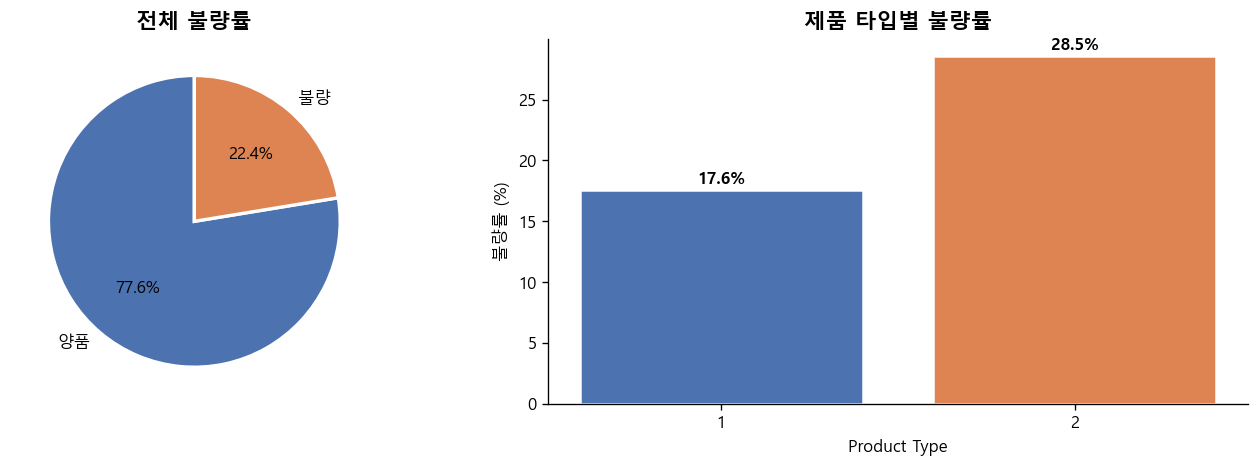

In [10]:
# ── 이진 타겟: 양품(0) / 불량(1) ────────────────────────────
df = df_raw.copy()
df['defect_any'] = ((df[defect_cols_1 + defect_cols_2].sum(axis=1)) > 0).astype(int)

total   = len(df)
n_bad   = df['defect_any'].sum()
n_good  = total - n_bad

print(f'전체 Shot   : {total:,}')
print(f'불량 Shot   : {n_bad:,}  ({n_bad/total*100:.1f}%)')
print(f'양품 Shot   : {n_good:,} ({n_good/total*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 파이 차트
axes[0].pie([n_good, n_bad], labels=['양품', '불량'],
            colors=PALETTE, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('전체 불량률', fontsize=13, fontweight='bold')

# 제품 타입별 불량률
type_defect = df.groupby('Process_Product_Type')['defect_any'].mean().reset_index()
type_defect.columns = ['Product_Type', 'Defect_Rate']
axes[1].bar(type_defect['Product_Type'].astype(str), type_defect['Defect_Rate']*100,
            color=PALETTE, edgecolor='white', linewidth=1.5)
axes[1].set_xlabel('Product Type')
axes[1].set_ylabel('불량률 (%)')
axes[1].set_title('제품 타입별 불량률', fontsize=13, fontweight='bold')
for i, row in type_defect.iterrows():
    axes[1].text(i, row['Defect_Rate']*100+0.5, f'{row["Defect_Rate"]*100:.1f}%',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


### 3-2. 불량 유형별 발생 빈도

**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: 이 단계의 코드 실행
- **왜**: 프로젝트 흐름을 이어가기 위한 처리 단계.
- **어떻게**: 셀 내용을 순서대로 실행.


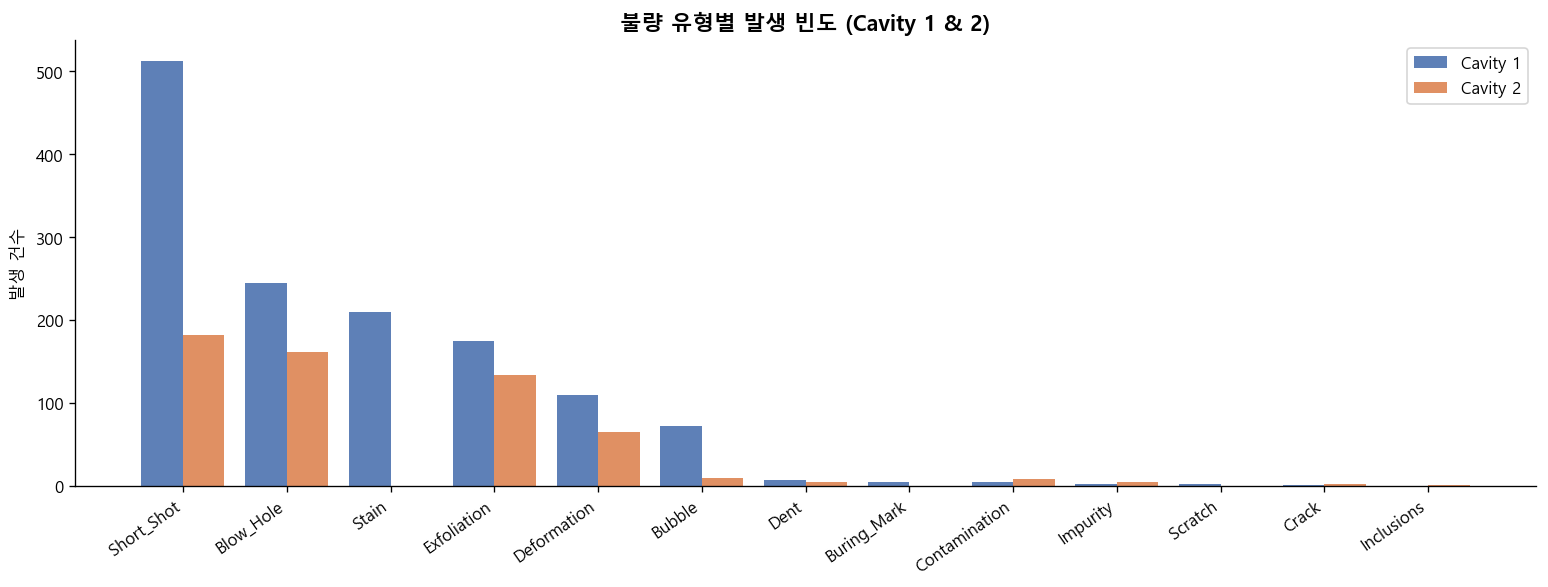


불량 유형별 합계 (Cavity 1 + 2):
Short_Shot       694
Blow_Hole        406
Exfoliation      309
Stain            209
Deformation      174
Bubble            81
Contamination     12
Dent              11
Impurity           7
Buring_Mark        5
Crack              3
Scratch            2
Inclusions         1
dtype: int64


In [11]:
# ── 불량 유형별 빈도 ─────────────────────────────────────────
defect_labels = ['Short_Shot','Bubble','Exfoliation','Blow_Hole','Stain',
                 'Dent','Deformation','Contamination','Impurity','Crack','Scratch','Buring_Mark','Inclusions']

counts_1 = {label: df[f'Defects_{label}_1'].sum() for label in defect_labels}
counts_2 = {label: df[f'Defects_{label}_2'].sum() for label in defect_labels}

defect_df = pd.DataFrame({'Cavity_1': counts_1, 'Cavity_2': counts_2}).sort_values('Cavity_1', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(defect_df))
w = 0.4
ax.bar(x - w/2, defect_df['Cavity_1'], width=w, label='Cavity 1', color=PALETTE[0], alpha=0.9)
ax.bar(x + w/2, defect_df['Cavity_2'], width=w, label='Cavity 2', color=PALETTE[1], alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(defect_df.index, rotation=35, ha='right')
ax.set_ylabel('발생 건수')
ax.set_title('불량 유형별 발생 빈도 (Cavity 1 & 2)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('\n불량 유형별 합계 (Cavity 1 + 2):')
print((defect_df['Cavity_1'] + defect_df['Cavity_2']).sort_values(ascending=False))


### 3-2-1. Top 3 불량 유형 다중분류 (NoDefect 포함 4-class)

> 불량 유형 분포(3-2) 결과를 바탕으로 **발생 빈도 상위 3개**를 자동 선정해 다중분류를 수행.

**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: 이진 타겟(defect_any) 생성: 양품(0) vs 불량(1)
- **왜**: 실무에서 1차 목표는 ‘불량 여부 조기 경보’인 경우가 많고, 데이터 불균형에도 비교적 강함.
- **어떻게**: 불량 관련 컬럼(여러 유형)을 합산해 1개라도 있으면 1, 없으면 0으로 변환.


In [12]:

# ============================================================
# STEP 2) Top 3 불량 유형 다중분류 (NoDefect 포함 4-class)
#   - 실제 데이터에서 발생 빈도 상위 3개 불량 라벨을 자동 선정
#   - 타겟: {NoDefect, DefectA, DefectB, DefectC}
#   - 모델: XGBoost multi-class
# ============================================================

import numpy as np
import pandas as pd

# --- 불량 컬럼 목록 확보 ---
defect_cols = []
if 'defect_cols_1' in globals() and 'defect_cols_2' in globals():
    defect_cols = list(defect_cols_1) + list(defect_cols_2)
else:
    # Defects_ 접두어 기반 자동 탐색
    defect_cols = [c for c in df.columns if c.startswith("Defects_")]

if not defect_cols:
    raise ValueError("불량(Defects_) 컬럼을 찾지 못했습니다.")

# --- 상위 3개 불량 유형 선정 (발생 건수 기준) ---
defect_counts = df[defect_cols].sum().sort_values(ascending=False)
top3 = defect_counts.head(3).index.tolist()

print("✅ Top 3 불량 유형(빈도 기준)")
display(pd.DataFrame({"defect": top3, "count": defect_counts.loc[top3].values}))

# --- 4-class 타겟 생성 ---
# 규칙: top3 중 하나라도 1이면 해당 라벨로 분류
#       (여러 개가 동시에 1이면 '가장 빈도가 높은(=top3 순서상 앞)' 불량으로 우선순위)
label_map = {top3[0]: "Top1_" + top3[0].replace("Defects_", ""),
             top3[1]: "Top2_" + top3[1].replace("Defects_", ""),
             top3[2]: "Top3_" + top3[2].replace("Defects_", "")}

y_mc = np.array(["NoDefect"] * len(df), dtype=object)
for col in top3:
    mask = (df[col].astype(int).values == 1) & (y_mc == "NoDefect")
    y_mc[mask] = label_map[col]

# 클래스 분포
dist = pd.Series(y_mc).value_counts()
print("\n✅ 4-class 분포")
display(dist.to_frame("count"))

# --- feature matrix 재사용 ---
# --- feature matrix 생성 (STEP 2는 STEP 1과 독립적으로 동작하도록 구성) ---
# 원칙: 불량 라벨(Defects_*)과 타깃(defect_any)은 피처에서 제외하고, 숫자형 변수만 사용
drop_cols = defect_cols + ["defect_any"]
candidate = df.drop(columns=drop_cols, errors="ignore")
X_mc = candidate.select_dtypes(include=[np.number]).copy()

# (안전) 혹시 Defects_ 컬럼이 남아있다면 한 번 더 제거
X_mc = X_mc.drop(columns=defect_cols, errors="ignore")
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc
)

# --- 모델 학습 (XGB multi-class) ---
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

classes = np.unique(y_mc)
class_to_idx = {c:i for i,c in enumerate(classes)}
y_tr_idx = np.array([class_to_idx[v] for v in y_tr])
y_te_idx = np.array([class_to_idx[v] for v in y_te])

xgb_mc = XGBClassifier(
    n_estimators=900,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="multi:softprob",
    num_class=len(classes),
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_mc.fit(X_tr, y_tr_idx)
proba_mc = xgb_mc.predict_proba(X_te)
pred_mc_idx = np.argmax(proba_mc, axis=1)
pred_mc = np.array([classes[i] for i in pred_mc_idx])

print("\n✅ Multi-class Test report (4-class)")
print(classification_report(y_te, pred_mc, digits=4))

print("✅ Confusion matrix (rows=true, cols=pred)")
cm = pd.DataFrame(confusion_matrix(y_te, pred_mc), index=classes, columns=classes)
display(cm)

# (후속 STEP에서 재사용)
top3_defects = top3
multiclass_model = xgb_mc
multiclass_classes = classes

# --- feature matrix 생성 (STEP 2는 STEP 1과 독립적으로 동작하도록 구성) ---
# 원칙: 불량 라벨(Defects_*)과 타깃(defect_any)은 피처에서 제외하고, 숫자형 변수만 사용
drop_cols = defect_cols + ["defect_any"]
candidate = df.drop(columns=drop_cols, errors="ignore")
X_mc = candidate.select_dtypes(include=[np.number]).copy()

# (안전) 혹시 Defects_ 컬럼이 남아있다면 한 번 더 제거
X_mc = X_mc.drop(columns=defect_cols, errors="ignore")

from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc
)

# --- 모델 학습 (XGB multi-class) ---
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

classes = np.unique(y_mc)
class_to_idx = {c:i for i,c in enumerate(classes)}
y_tr_idx = np.array([class_to_idx[v] for v in y_tr])
y_te_idx = np.array([class_to_idx[v] for v in y_te])

xgb_mc = XGBClassifier(
    n_estimators=900,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="multi:softprob",
    num_class=len(classes),
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_mc.fit(X_tr, y_tr_idx)
proba_mc = xgb_mc.predict_proba(X_te)
pred_mc_idx = np.argmax(proba_mc, axis=1)
pred_mc = np.array([classes[i] for i in pred_mc_idx])

print("\n✅ Multi-class Test report (4-class)")
print(classification_report(y_te, pred_mc, digits=4))

print("✅ Confusion matrix (rows=true, cols=pred)")
cm = pd.DataFrame(confusion_matrix(y_te, pred_mc), index=classes, columns=classes)
display(cm)

# (후속 STEP에서 재사용)
top3_defects = top3
multiclass_model = xgb_mc
multiclass_classes = classes


✅ Top 3 불량 유형(빈도 기준)


,defect,count
0,Defects_Short_Shot_1,512
1,Defects_Blow_Hole_1,245
2,Defects_Stain_1,209



✅ 4-class 분포


,count
NoDefect,6717
Top1_Short_Shot_1,482
Top2_Blow_Hole_1,193
Top3_Stain_1,143



✅ Multi-class Test report (4-class)
                   precision    recall  f1-score   support

         NoDefect     0.9672    0.9866    0.9768      1343
Top1_Short_Shot_1     0.7973    0.6146    0.6941        96
 Top2_Blow_Hole_1     0.9143    0.8205    0.8649        39
     Top3_Stain_1     0.9286    0.8966    0.9123        29

         accuracy                         0.9569      1507
        macro avg     0.9018    0.8296    0.8620      1507
     weighted avg     0.9542    0.9569    0.9546      1507

✅ Confusion matrix (rows=true, cols=pred)


,NoDefect,Top1_Short_Shot_1,Top2_Blow_Hole_1,Top3_Stain_1
NoDefect,1325,15,3,0
Top1_Short_Shot_1,35,59,0,2
Top2_Blow_Hole_1,7,0,32,0
Top3_Stain_1,3,0,0,26



✅ Multi-class Test report (4-class)
                   precision    recall  f1-score   support

         NoDefect     0.9672    0.9866    0.9768      1343
Top1_Short_Shot_1     0.7973    0.6146    0.6941        96
 Top2_Blow_Hole_1     0.9143    0.8205    0.8649        39
     Top3_Stain_1     0.9286    0.8966    0.9123        29

         accuracy                         0.9569      1507
        macro avg     0.9018    0.8296    0.8620      1507
     weighted avg     0.9542    0.9569    0.9546      1507

✅ Confusion matrix (rows=true, cols=pred)


,NoDefect,Top1_Short_Shot_1,Top2_Blow_Hole_1,Top3_Stain_1
NoDefect,1325,15,3,0
Top1_Short_Shot_1,35,59,0,2
Top2_Blow_Hole_1,7,0,32,0
Top3_Stain_1,3,0,0,26


### 3-3. 공정 변수 분포 (양품 vs 불량 비교)

**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: 이진 타겟(defect_any) 생성: 양품(0) vs 불량(1)
- **왜**: 실무에서 1차 목표는 ‘불량 여부 조기 경보’인 경우가 많고, 데이터 불균형에도 비교적 강함.
- **어떻게**: 불량 관련 컬럼(여러 유형)을 합산해 1개라도 있으면 1, 없으면 0으로 변환.


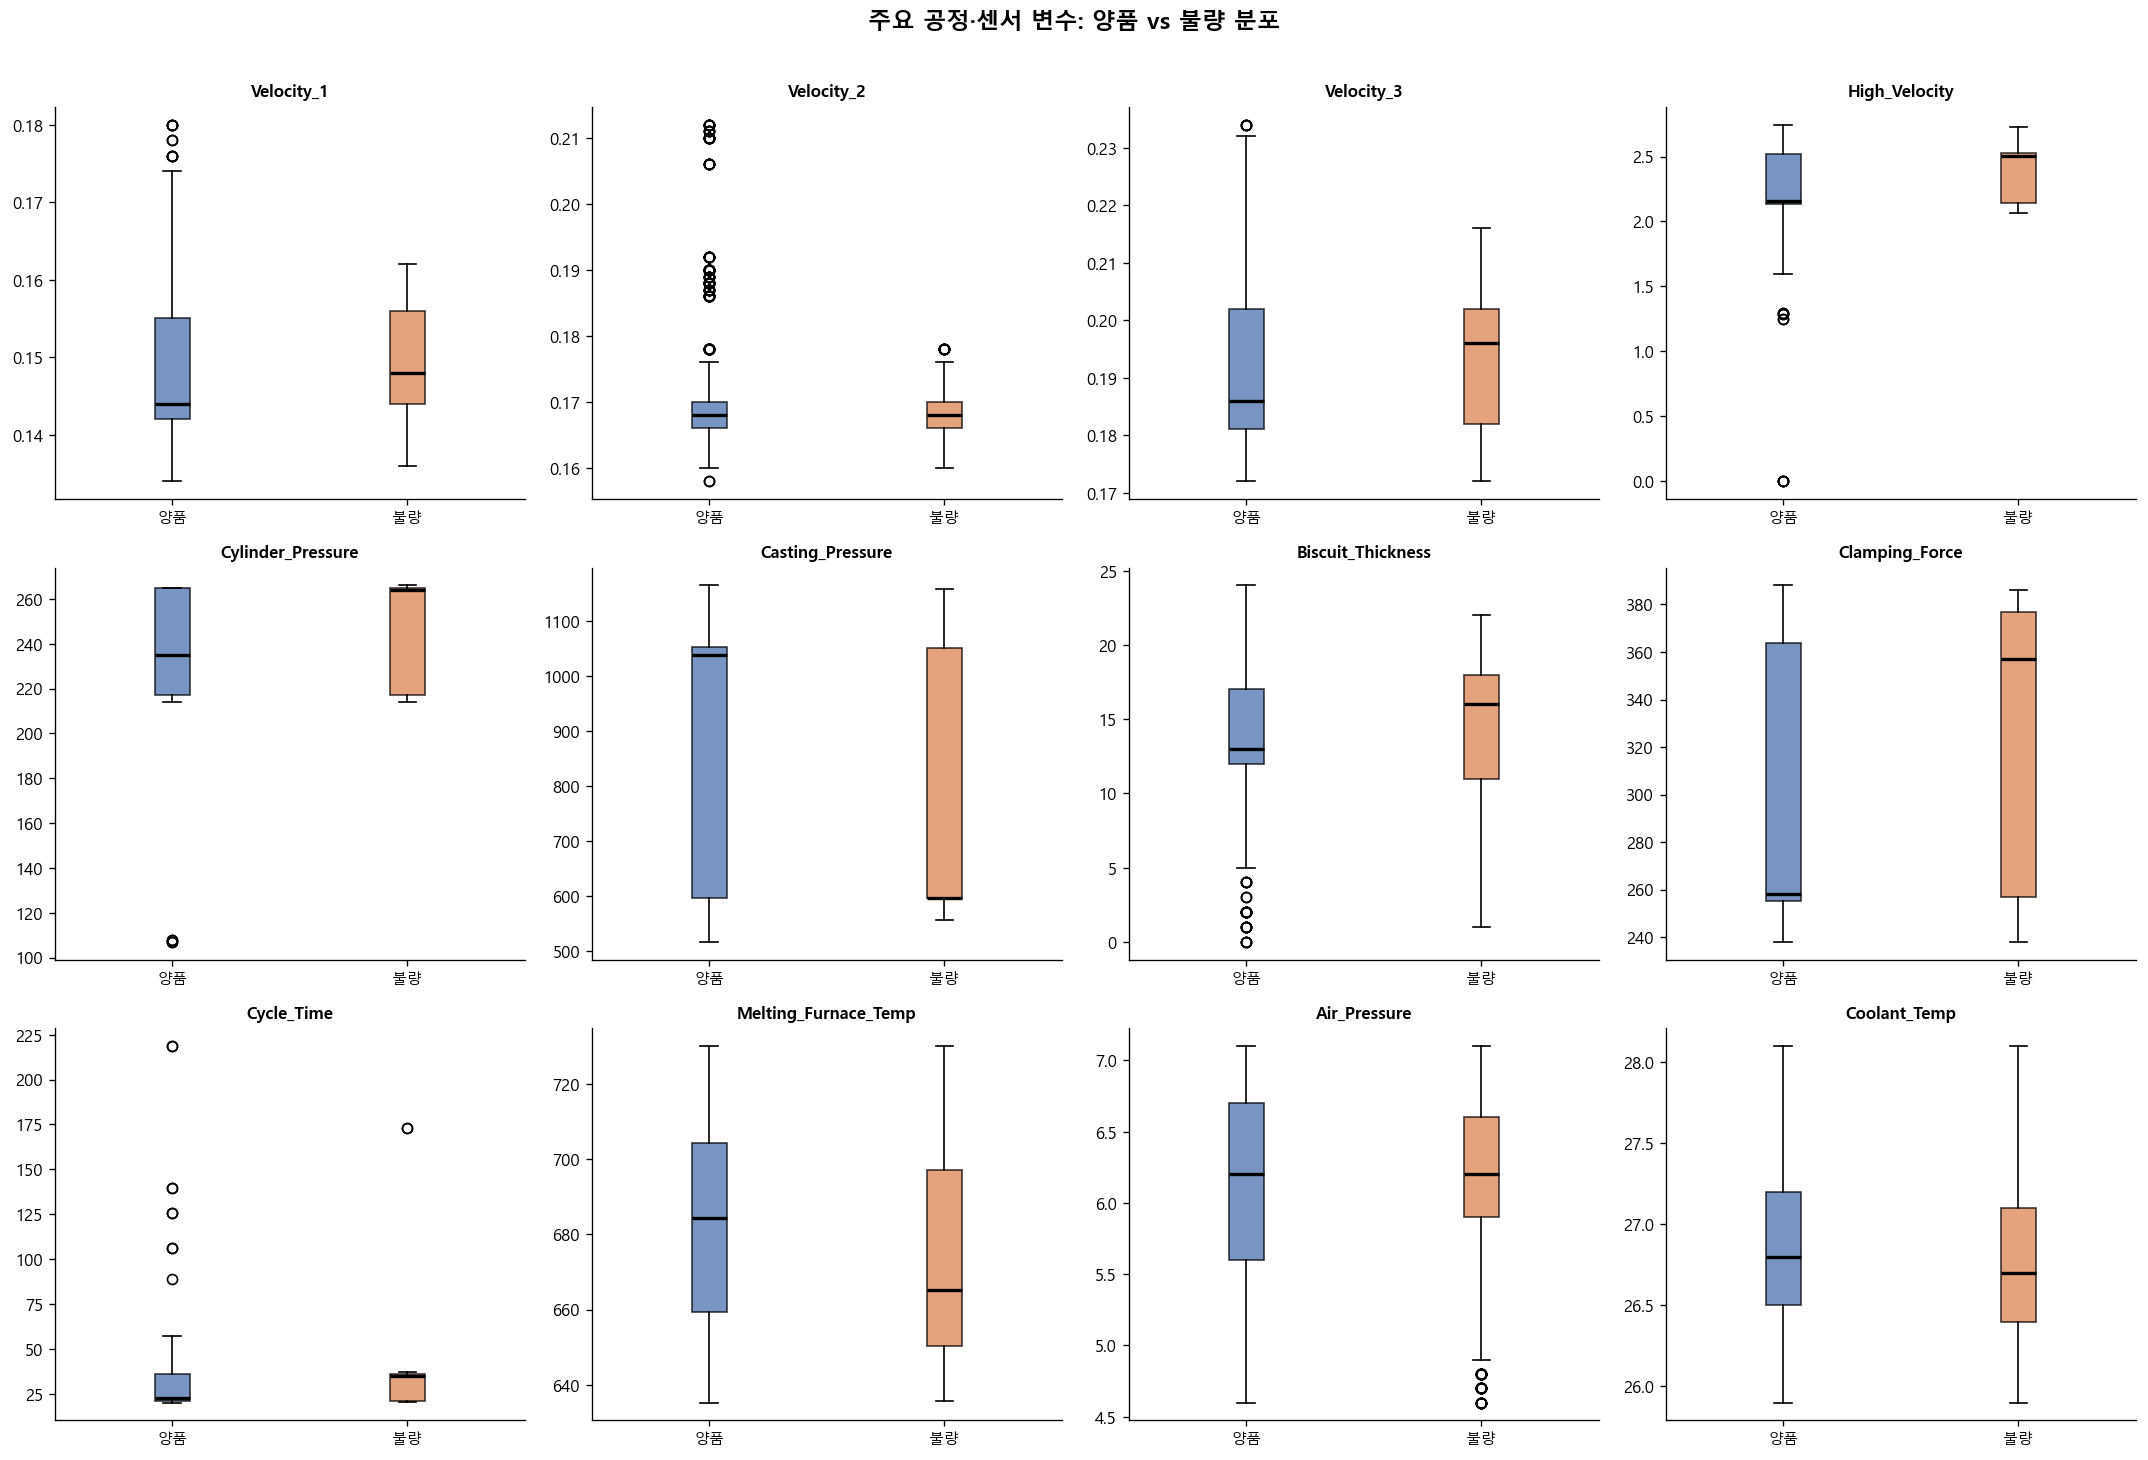

In [13]:
# ── 박스플롯: 주요 공정 변수 양품 vs 불량 ───────────────────
# 데이터 컬럼이 'Process_*'/'Sensor_*'로 구성되어 있고, 원본에 공백이 섞여 있을 수 있어
# 존재하는 컬럼 기준으로 안전하게 매핑.

# (원래 의도한 변수명 → 실제 데이터 컬럼명)
col_map = {
    "Process_Melting_Furnace_Temp": "Sensor_Melting_Furnace_Temp",
    "Process_Coolant_Temp": "Sensor_Coolant_Temp",
    "Process_Air_Pressure": "Sensor_Air_Pressure",
}

key_vars_candidate = [
    'Process_Velocity_1','Process_Velocity_2','Process_Velocity_3',
    'Process_High_Velocity','Process_Cylinder_Pressure',
    'Process_Casting_Pressure','Process_Biscuit_Thickness',
    'Process_Clamping_Force','Process_Cycle_Time',
    # 아래 3개는 데이터상 Sensor_* 로 들어오는 경우가 많음
    'Process_Melting_Furnace_Temp','Process_Air_Pressure','Process_Coolant_Temp'
]

# 실제 존재하는 컬럼으로 정리
key_vars = []
missing = []
for c in key_vars_candidate:
    c2 = col_map.get(c, c)
    if c2 in df.columns:
        key_vars.append(c2)
    else:
        missing.append(c)

# 누락이 있으면 알려주되, 셀은 계속 실행되게 함
if missing:
    print("⚠️ 박스플롯에서 제외된(미존재) 컬럼:", missing)

n = len(key_vars)
rows = (n + 3) // 4
fig, axes = plt.subplots(rows, 4, figsize=(18, 4*rows))
axes = axes.flatten()

for i, col in enumerate(key_vars):
    data_good = df[df['defect_any'] == 0][col]
    data_bad  = df[df['defect_any'] == 1][col]
    bp = axes[i].boxplot([data_good.dropna(), data_bad.dropna()],
                          labels=['양품', '불량'],
                          patch_artist=True,
                          medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(PALETTE[0])
    bp['boxes'][1].set_facecolor(PALETTE[1])
    for patch in bp['boxes']:
        patch.set_alpha(0.75)
    short_name = col.replace('Process_','').replace('Sensor_','')
    axes[i].set_title(short_name, fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', labelsize=9)

# 남는 축 비우기
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.suptitle('주요 공정·센서 변수: 양품 vs 불량 분포', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 3-4. 상관 행렬 (공정 변수)

**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: Process/Sensor/Defect 컬럼을 자동으로 분류
- **왜**: 이후 EDA·모델링에서 어떤 컬럼을 입력 피처로 쓸지 일관되게 관리하기 위해서.
- **어떻게**: 컬럼 접두어(`Process_`, `Sensor_`)와 불량 라벨 패턴을 이용해 리스트를 만듦.


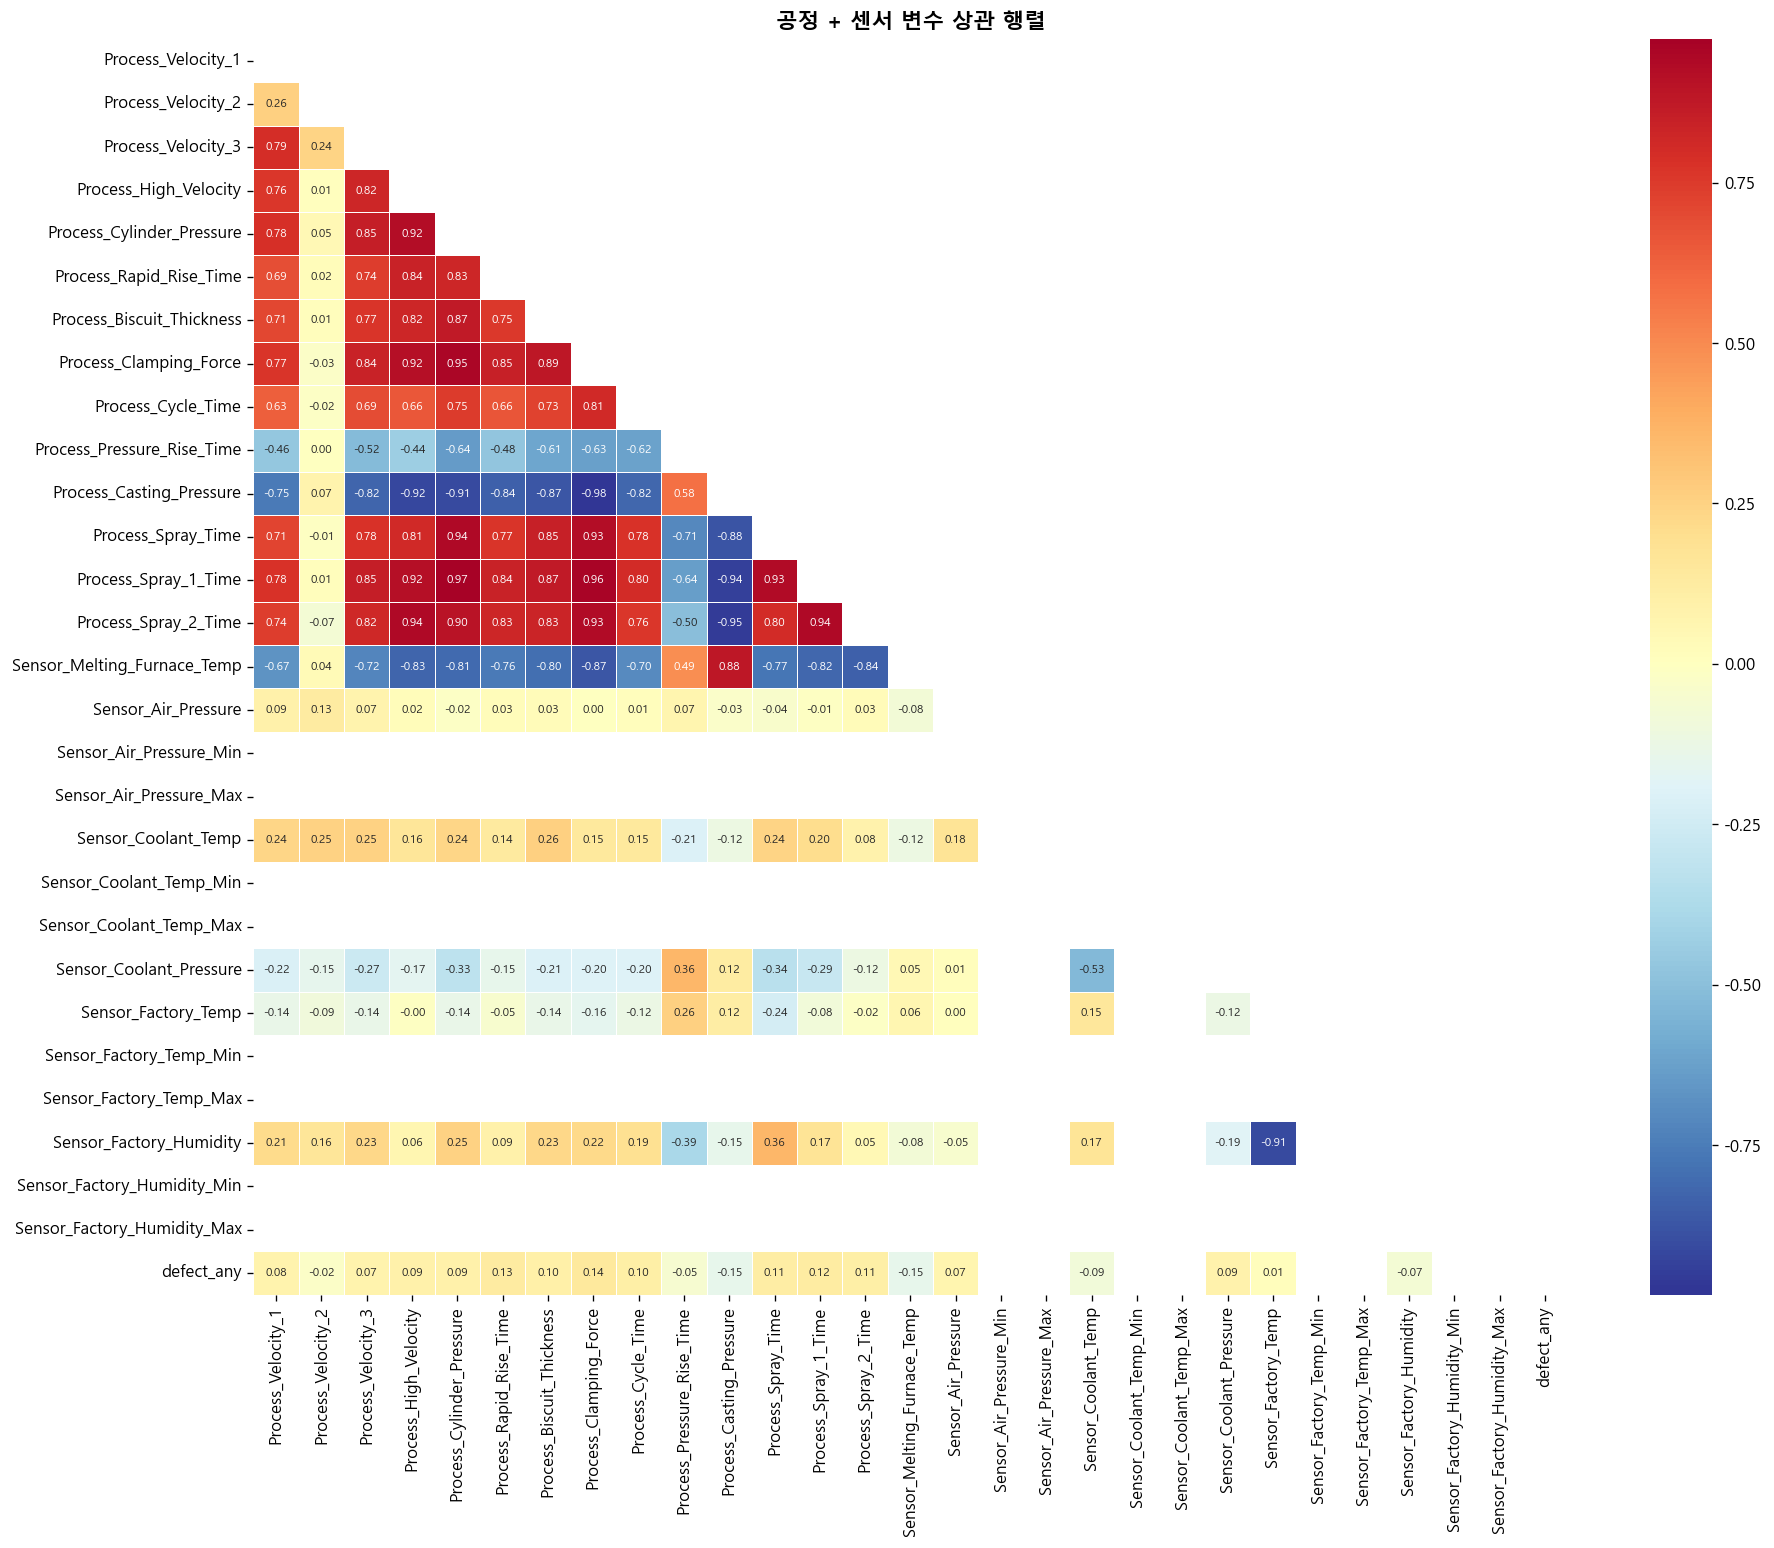


📌 불량(defect_any)과 상관관계 높은 변수 TOP 10:
Sensor_Melting_Furnace_Temp   0.1456
Process_Casting_Pressure      0.1452
Process_Clamping_Force        0.1428
Process_Rapid_Rise_Time       0.1327
Process_Spray_1_Time          0.1248
Process_Spray_Time            0.1110
Process_Spray_2_Time          0.1062
Process_Cycle_Time            0.1042
Process_Biscuit_Thickness     0.0959
Process_Cylinder_Pressure     0.0932
Name: defect_any, dtype: float64


In [14]:
# ── 상관 행렬 ────────────────────────────────────────────────
corr_df = df[process_cols + sensor_cols + ['defect_any']].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, linewidths=0.4, ax=ax,
            annot_kws={'size': 7})
ax.set_title('공정 + 센서 변수 상관 행렬', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# defect_any 상관관계 TOP
print('\n📌 불량(defect_any)과 상관관계 높은 변수 TOP 10:')
print(corr_df['defect_any'].drop('defect_any').abs().sort_values(ascending=False).head(10))


### 3-5. 이상치 탐색 (IQR 방법)

**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: Process/Sensor/Defect 컬럼을 자동으로 분류
- **왜**: 이후 EDA·모델링에서 어떤 컬럼을 입력 피처로 쓸지 일관되게 관리하기 위해서.
- **어떻게**: 컬럼 접두어(`Process_`, `Sensor_`)와 불량 라벨 패턴을 이용해 리스트를 만듦.


이상치 비율 TOP 15:
Sensor_Factory_Temp            2.69 %
Process_Velocity_2             2.44 %
Process_Biscuit_Thickness      0.16 %
Process_Cycle_Time             0.15 %
Process_Rapid_Rise_Time        0.13 %
Process_High_Velocity          0.13 %
Process_Velocity_1             0.08 %
Process_Velocity_3             0.05 %
Process_Pressure_Rise_Time     0.05 %
Process_Cylinder_Pressure      0.05 %
Process_Casting_Pressure        0.0 %
Process_Clamping_Force          0.0 %
Process_Spray_Time              0.0 %
Process_Spray_1_Time            0.0 %
Sensor_Melting_Furnace_Temp     0.0 %
dtype: object


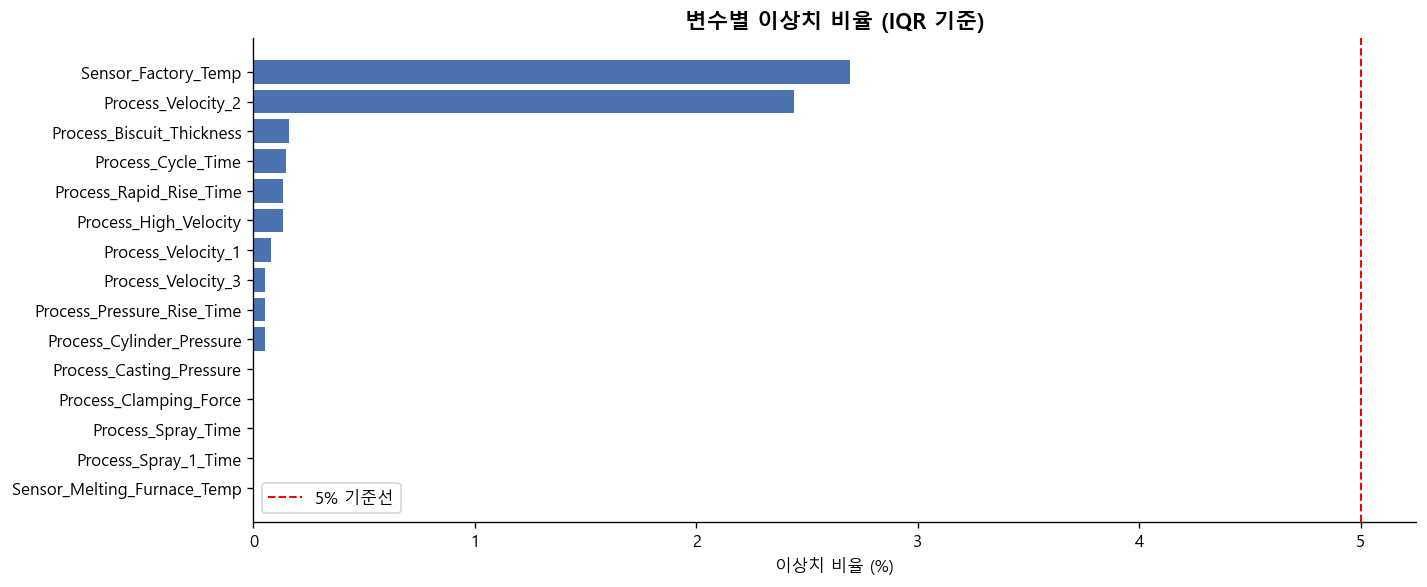

In [15]:
# ── IQR 기반 이상치 비율 ─────────────────────────────────────
def outlier_ratio(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).mean()

outlier_rates = {col: outlier_ratio(df[col]) for col in process_cols + sensor_cols}
outlier_series = pd.Series(outlier_rates).sort_values(ascending=False)

print('이상치 비율 TOP 15:')
print((outlier_series.head(15) * 100).round(2).astype(str) + ' %')

fig, ax = plt.subplots(figsize=(12, 5))
top15 = outlier_series.head(15)
colors = ['#e74c3c' if v > 0.05 else '#4C72B0' for v in top15.values]
ax.barh(top15.index[::-1], top15.values[::-1] * 100, color=colors[::-1])
ax.axvline(5, color='red', linestyle='--', linewidth=1.2, label='5% 기준선')
ax.set_xlabel('이상치 비율 (%)')
ax.set_title('변수별 이상치 비율 (IQR 기준)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


### 3-6. 통계 검정: t-test (양품 vs 불량)

**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: Process/Sensor/Defect 컬럼을 자동으로 분류
- **왜**: 이후 EDA·모델링에서 어떤 컬럼을 입력 피처로 쓸지 일관되게 관리하기 위해서.
- **어떻게**: 컬럼 접두어(`Process_`, `Sensor_`)와 불량 라벨 패턴을 이용해 리스트를 만듦.


In [16]:
# ── Welch's t-test ────────────────────────────────────────────
# welch's t-test를 사용한 이유 - 지금 데이터는 불균형이며, 샘플 수 차이가 크기 때문임
from scipy import stats

results = []
good_mask = df['defect_any'] == 0
bad_mask  = df['defect_any'] == 1

for col in process_cols + sensor_cols:
    g = df.loc[good_mask, col].dropna()
    b = df.loc[bad_mask,  col].dropna()
    t_stat, p_val = stats.ttest_ind(g, b, equal_var=False)
    results.append({
        'variable': col,
        'mean_good': g.mean(),
        'mean_bad':  b.mean(),
        'diff':      b.mean() - g.mean(),
        't_stat':    t_stat,
        'p_value':   p_val,
        'significant': '★ 유의' if p_val < 0.05 else '비유의'
    })

ttest_df = pd.DataFrame(results).sort_values('p_value')
print('유의한 변수 (p < 0.05):')
sig = ttest_df[ttest_df['significant'] == '★ 유의']
print(sig[['variable','mean_good','mean_bad','diff','p_value']].to_string(index=False))


유의한 변수 (p < 0.05):
                   variable  mean_good  mean_bad     diff  p_value
Sensor_Melting_Furnace_Temp   682.6312  673.8044  -8.8268   0.0000
   Process_Casting_Pressure   875.2633  793.5376 -81.7257   0.0000
     Process_Clamping_Force   302.0364  321.6519  19.6154   0.0000
    Process_Rapid_Rise_Time     0.0094    0.0101   0.0007   0.0000
       Process_Spray_1_Time     1.3717    1.5385   0.1668   0.0000
       Process_Spray_2_Time     1.3552    1.5375   0.1823   0.0000
         Process_Spray_Time     9.7061   10.1964   0.4903   0.0000
         Process_Cycle_Time    27.2477   29.4259   2.1782   0.0000
      Process_High_Velocity     2.3081    2.3577   0.0496   0.0000
  Process_Biscuit_Thickness    14.1403   14.8958   0.7555   0.0000
    Sensor_Coolant_Pressure     2.6987    2.7095   0.0107   0.0000
  Process_Cylinder_Pressure   238.4880  243.6969   5.2088   0.0000
        Sensor_Coolant_Temp    26.8543   26.7465  -0.1077   0.0000
         Process_Velocity_1     0.1479    0

## 4️⃣ 데이터 전처리

**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: Process/Sensor/Defect 컬럼을 자동으로 분류
- **왜**: 이후 EDA·모델링에서 어떤 컬럼을 입력 피처로 쓸지 일관되게 관리하기 위해서.
- **어떻게**: 컬럼 접두어(`Process_`, `Sensor_`)와 불량 라벨 패턴을 이용해 리스트를 만듦.


In [17]:
# ── 피처 & 타겟 정의 ─────────────────────────────────────────
feature_cols = process_cols + sensor_cols
X = df[feature_cols].copy()
y = df['defect_any'].copy()

print(f'Feature shape : {X.shape}')
print(f'Target 분포   :\n{y.value_counts()}')


Feature shape : (7535, 28)
Target 분포   :
defect_any
0    5846
1    1689
Name: count, dtype: int64


**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: 결측치(빈 값) 규모 확인
- **왜**: 결측치가 많으면 모델이 왜곡되거나 오류가 날 수 있어, 먼저 현황을 파악해야 함.
- **어떻게**: 컬럼별 결측치 개수 합계와 결측치가 존재하는 컬럼만 출력.


In [18]:
# ── 결측치 처리 (중앙값 대체) ────────────────────────────────
# 중앙값으로 대체한 이유 - 불균형 데이터 -> 이상치 존재 가능성이 있음(예를 들면 제조 데이터에서의 센서 오류?) -> 고로 평균보다 중앙값이 합리적이라 판단했음.
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)

print('결측치 처리 후:', X_imp.isnull().sum().sum(), '개')


결측치 처리 후: 0 개


**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: 이상치 완화(IQR 클리핑)
- **왜**: 극단값이 모델을 과하게 흔드는 것을 줄여 안정적인 학습을 도움.
- **어떻게**: IQR 범위 기반 상·하한을 계산하고, 그 밖의 값은 경계값으로 잘라냄.


In [19]:
# ── IQR 클리핑 (이상치 처리) ─────────────────────────────────
def clip_iqr(df_in, factor=3.0):
    df_out = df_in.copy()
    for col in df_out.columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        df_out[col] = df_out[col].clip(Q1 - factor*IQR, Q3 + factor*IQR)
    return df_out

X_clipped = clip_iqr(X_imp, factor=3.0)
print('IQR 클리핑 완료 (factor=3.0)')


IQR 클리핑 완료 (factor=3.0)


**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: 학습/테스트 데이터 분할
- **왜**: 학습에 사용하지 않은 데이터로 성능을 평가해야 실제 적용 성능을 추정할 수 있음.
- **어떻게**: 불량 비율을 유지(stratify)한 채로 8:2로 나눔.


In [20]:
# ── 학습 / 테스트 분할 ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_clipped, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train 불량률: {y_train.mean()*100:.1f}%  |  Test 불량률: {y_test.mean()*100:.1f}%')


Train: (6028, 28)  |  Test: (1507, 28)
Train 불량률: 22.4%  |  Test 불량률: 22.4%


## 5️⃣ 머신러닝 모델 학습 & 평가

### 5-1. Leak-free CV · Calibration · 비용 기반 Threshold

> 기존 5️⃣ 모델 학습 흐름은 유지하되, **누수 방지 CV + 확률 보정 + 비용 기반 의사결정**을 한 번에 점검합니다.

**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: 이진 타겟(defect_any) 생성: 양품(0) vs 불량(1)
- **왜**: 실무에서 1차 목표는 ‘불량 여부 조기 경보’인 경우가 많고, 데이터 불균형에도 비교적 강함.
- **어떻게**: 불량 관련 컬럼(여러 유형)을 합산해 1개라도 있으면 1, 없으면 0으로 변환함.


In [21]:

# ============================================================
# STEP 1) Binary 모델 완성도 강화
#   - Leak-free CV: SMOTE를 CV fold 내부에서만 적용 (imblearn Pipeline)
#   - 지표: ROC-AUC + PR-AUC + (정밀도/재현율/F1) + Calibration
#   - 비용 기반 threshold: FN 비용이 FP보다 큰 상황 가정하여 최적 threshold 탐색
# ============================================================

import numpy as np
import pandas as pd

# --- (안전) 기존 노트북 변수 재사용, 없으면 로드/구성 ---
if 'df' not in globals():
    raise NameError("df 변수가 없습니다. 위쪽 셀에서 데이터 로드/전처리를 먼저 실행하세요.")
if 'defect_any' not in df.columns:
    raise KeyError("df에 defect_any 컬럼이 없습니다. 위쪽 셀에서 defect_any 생성 셀을 먼저 실행하세요.")

# --- feature matrix 생성/재사용 (STEP1에서 X를 확정합니다) ---
# 우선순위: (1) X_clipped가 있으면 사용 (2) X가 있으면 사용 (3) df에서 자동 생성
if "X_clipped" in globals():
    X = X_clipped.copy()
elif "X" in globals():
    X = X.copy()
else:
    drop_cols = [c for c in df.columns if c.startswith('Defects_')] + ['defect_any']
    candidate = df.drop(columns=drop_cols, errors='ignore')
    X = candidate.select_dtypes(include=[np.number]).copy()

y_bin = df['defect_any'].astype(int).values

# --- train/test split (기존 변수가 있으면 그대로 재사용) ---
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
if all(k in globals() for k in ['X_train','X_test','y_train','y_test']):
    X_train_, X_test_, y_train_, y_test_ = X_train, X_test, y_train, y_test
else:
    X_train_, X_test_, y_train_, y_test_ = train_test_split(
        X, y_bin, test_size=0.2, random_state=42, stratify=y_bin
    )

# --- Leak-free Pipeline: SMOTE inside CV ---
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix,
                             precision_recall_curve, brier_score_loss)
from sklearn.calibration import CalibratedClassifierCV

xgb_bin = XGBClassifier(
    n_estimators=700,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

pipe_bin = Pipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("model", xgb_bin)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

cv_res = cross_validate(pipe_bin, X_train_, y_train_, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
print("✅ Leak-free CV 성능(Train only)")
for k, v in cv_res.items():
    if k.startswith("test_"):
        metric = k.replace("test_", "")
        print(f"- {metric:10s}: {np.mean(v):.4f} ± {np.std(v):.4f}")

# --- Fit final model on full train (with SMOTE) ---
pipe_bin.fit(X_train_, y_train_)
proba_test = pipe_bin.predict_proba(X_test_)[:, 1]

print("\n✅ Test 성능")
print(f"- ROC-AUC : {roc_auc_score(y_test_, proba_test):.4f}")
print(f"- PR-AUC  : {average_precision_score(y_test_, proba_test):.4f}")

# --- Calibration (확률 신뢰도) ---
# CalibratedClassifierCV는 내부적으로 CV를 수행하므로, 여기서는 '학습용 데이터'로만 fit
cal = CalibratedClassifierCV(pipe_bin, method="sigmoid", cv=3)
cal.fit(X_train_, y_train_)
proba_cal = cal.predict_proba(X_test_)[:, 1]

print("\n✅ Calibration (확률 신뢰도)")
print(f"- Brier score (raw) : {brier_score_loss(y_test_, proba_test):.4f}")
print(f"- Brier score (cal) : {brier_score_loss(y_test_, proba_cal):.4f}")

# --- 비용 기반 threshold 최적화 ---
# 현장 가정: 불량(FN)을 놓치는 비용이 FP보다 큼 (예: FN=10, FP=1)
FN_COST = 10
FP_COST = 1

prec, rec, thr = precision_recall_curve(y_test_, proba_cal)
thr = np.append(thr, 1.0)  # PR curve 특성상 threshold 길이 보정

# 각 threshold에서의 confusion matrix 기반 비용 계산
costs = []
for t in thr:
    y_pred = (proba_cal >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_, y_pred).ravel()
    cost = fn * FN_COST + fp * FP_COST
    costs.append(cost)

best_idx = int(np.argmin(costs))
best_t = float(thr[best_idx])

print("\n✅ 비용 기반 최적 threshold")
print(f"- FN_COST={FN_COST}, FP_COST={FP_COST}")
print(f"- Best threshold: {best_t:.4f}  |  Min cost: {costs[best_idx]:,.0f}")

# --- 최적 threshold 성능 리포트 ---
y_pred_best = (proba_cal >= best_t).astype(int)
print("\n[Classification report @ best threshold]")
print(classification_report(y_test_, y_pred_best, digits=4))

# (후속 STEP에서 재사용) 최종 객체 저장
best_threshold = best_t
binary_pipe_final = pipe_bin
binary_calibrated = cal
binary_test_proba_cal = proba_cal


✅ Leak-free CV 성능(Train only)
- roc_auc   : 0.8458 ± 0.0052
- pr_auc    : 0.6433 ± 0.0189
- f1        : 0.5664 ± 0.0327
- precision : 0.6633 ± 0.0379
- recall    : 0.4952 ± 0.0373

✅ Test 성능
- ROC-AUC : 0.8668
- PR-AUC  : 0.6888

✅ Calibration (확률 신뢰도)
- Brier score (raw) : 0.1134
- Brier score (cal) : 0.1141

✅ 비용 기반 최적 threshold
- FN_COST=10, FP_COST=1
- Best threshold: 0.1390  |  Min cost: 692

[Classification report @ best threshold]
              precision    recall  f1-score   support

           0     0.9614    0.6818    0.7978      1169
           1     0.4513    0.9053    0.6024       338

    accuracy                         0.7319      1507
   macro avg     0.7064    0.7936    0.7001      1507
weighted avg     0.8470    0.7319    0.7540      1507



### 5-2. 최종 Binary 모델 평가 (Test set)
- STEP1에서 학습한 `binary_calibrated`와 비용 기반 `best_threshold`를 사용합니다.

**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: Binary 모델 성능 시각화(ROC/PR/혼동행렬)
- **왜**: 단일 점수만으로는 판단이 어려워, 운영 관점에서 trade-off를 시각적으로 확인하기 위해서.
- **어떻게**: 예측 확률로 ROC·PR 곡선을 그리고, 선택한 threshold에서 혼동행렬을 계산함.


[Test] ROC-AUC: 0.8755 | PR-AUC: 0.6940 | threshold*: 0.139

[Classification Report @ threshold*]
              precision    recall  f1-score   support

           0     0.9614    0.6818    0.7978      1169
           1     0.4513    0.9053    0.6024       338

    accuracy                         0.7319      1507
   macro avg     0.7064    0.7936    0.7001      1507
weighted avg     0.8470    0.7319    0.7540      1507



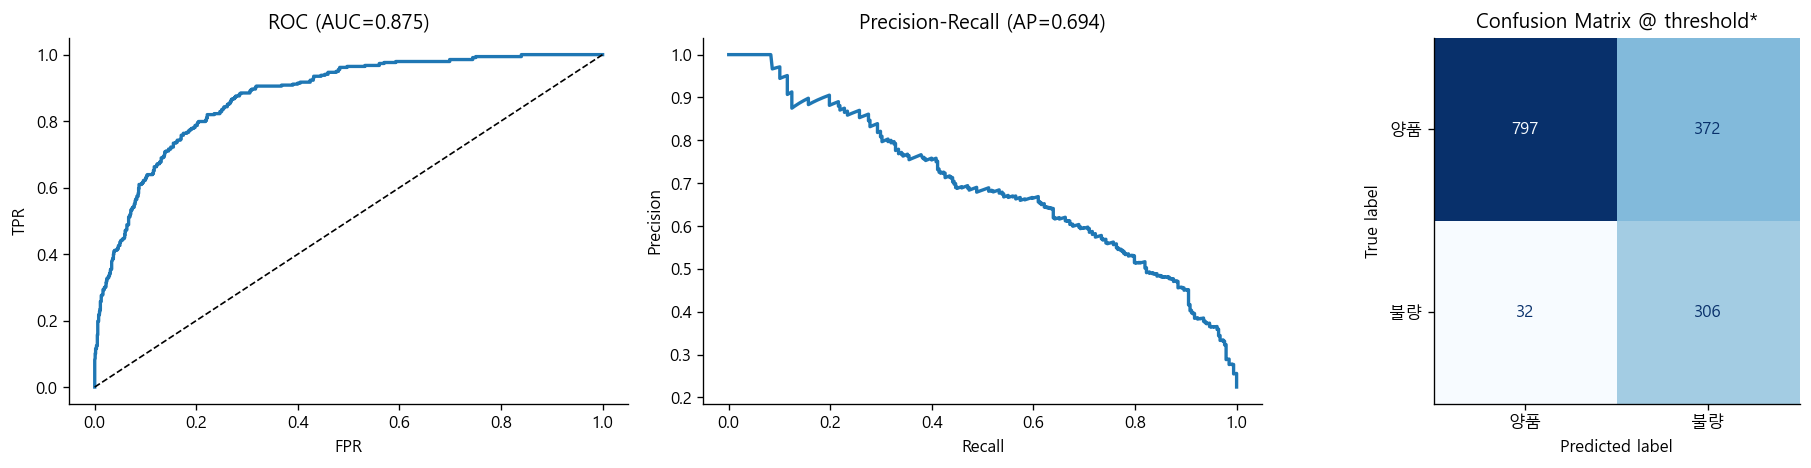

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 필수 객체 확인
if 'binary_calibrated' not in globals():
    raise NameError("binary_calibrated가 없습니다. STEP1 셀을 먼저 실행하세요.")
if 'best_threshold' not in globals():
    raise NameError("best_threshold가 없습니다. STEP1 셀을 먼저 실행하세요.")
if not all(k in globals() for k in ['X_test_', 'y_test_']):
    raise NameError("X_test_ / y_test_가 없습니다. STEP1 셀을 먼저 실행하세요.")

proba = binary_calibrated.predict_proba(X_test_)[:, 1]
thr = float(best_threshold)
pred = (proba >= thr).astype(int)

# ROC / PR
roc = roc_auc_score(y_test_, proba)
pr  = average_precision_score(y_test_, proba)

print(f"[Test] ROC-AUC: {roc:.4f} | PR-AUC: {pr:.4f} | threshold*: {thr:.3f}")
print("\n[Classification Report @ threshold*]")
print(classification_report(y_test_, pred, digits=4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ROC
fpr, tpr, _ = roc_curve(y_test_, proba)
axes[0].plot(fpr, tpr, linewidth=2)
axes[0].plot([0,1],[0,1],'k--', linewidth=1)
axes[0].set_title(f"ROC (AUC={roc:.3f})")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")

# PR
prec, rec, _ = precision_recall_curve(y_test_, proba)
axes[1].plot(rec, prec, linewidth=2)
axes[1].set_title(f"Precision-Recall (AP={pr:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")

# Confusion matrix
cm = confusion_matrix(y_test_, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["양품","불량"])
disp.plot(ax=axes[2], colorbar=False, cmap="Blues")
axes[2].set_title("Confusion Matrix @ threshold*")

plt.tight_layout()
plt.show()


## 6️⃣ 중요 변수 분석
- Permutation Importance(검증셋 기반) + XGBoost 내장 중요도를 함께 확인합니다.

**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: 특성 중요도(퍼뮤테이션 중요도) 산출
- **왜**: 어떤 변수가 예측에 실제로 기여했는지 설명력을 높이고, 공정 개선 포인트를 찾기 위해서.
- **어떻게**: 한 변수씩 값을 섞어 성능 저하량을 측정해 중요도를 계산함.


In [23]:
import pandas as pd
from sklearn.inspection import permutation_importance

# STEP1에서 학습한 파이프라인/모델 사용
if 'binary_pipe_final' not in globals():
    raise NameError("binary_pipe_final이 없습니다. STEP1 셀을 먼저 실행하세요.")
if not all(k in globals() for k in ['X_test_', 'y_test_']):
    raise NameError("X_test_ / y_test_가 없습니다. STEP1 셀을 먼저 실행하세요.")

# Permutation Importance (ROC-AUC 기준)
pi = permutation_importance(
    binary_pipe_final, X_test_, y_test_,
    scoring="roc_auc", n_repeats=10, random_state=42, n_jobs=-1
)
pi_df = (pd.DataFrame({"feature": X_test_.columns, "importance": pi.importances_mean})
           .sort_values("importance", ascending=False)
           .head(15))
display(pi_df)

# XGBoost gain 기반 중요도(참고)
xgb_model = binary_pipe_final.named_steps["model"]
try:
    booster = xgb_model.get_booster()
    gain = booster.get_score(importance_type="gain")
    gain_df = (pd.DataFrame({"feature": list(gain.keys()), "gain": list(gain.values())})
                 .sort_values("gain", ascending=False)
                 .head(15))
    display(gain_df)
except Exception as e:
    print("⚠️ XGBoost gain importance 계산 실패:", e)


,feature,importance
3,Process_High_Velocity,0.0745
10,Process_Casting_Pressure,0.0341
14,Sensor_Melting_Furnace_Temp,0.0323
15,Sensor_Air_Pressure,0.0299
21,Sensor_Coolant_Pressure,0.0277
25,Sensor_Factory_Humidity,0.0249
8,Process_Cycle_Time,0.0207
2,Process_Velocity_3,0.0203
6,Process_Biscuit_Thickness,0.0196
12,Process_Spray_1_Time,0.0190


,feature,gain
12,Process_Spray_1_Time,54.5289
13,Process_Spray_2_Time,49.9024
5,Process_Rapid_Rise_Time,12.5918
6,Process_Biscuit_Thickness,12.2741
1,Process_Velocity_2,11.5174
10,Process_Casting_Pressure,10.4406
4,Process_Cylinder_Pressure,8.5180
0,Process_Velocity_1,8.3328
17,Sensor_Coolant_Pressure,6.7513
3,Process_High_Velocity,5.7797


## 7️⃣ SHAP 해석
- STEP1의 최종 XGBoost 모델을 기반으로 전역/국소 해석을 수행합니다.

**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: SHAP 해석(모델이 예측한 이유를 설명)
- **왜**: 제조 현장에서는 ‘왜 불량으로 판단했는지’가 매우 중요하기 때문.
- **어떻게**: TreeExplainer/Explainer로 SHAP 값을 계산하고 summary/dependence 등으로 시각화.


SHAP shape: (1200, 28)


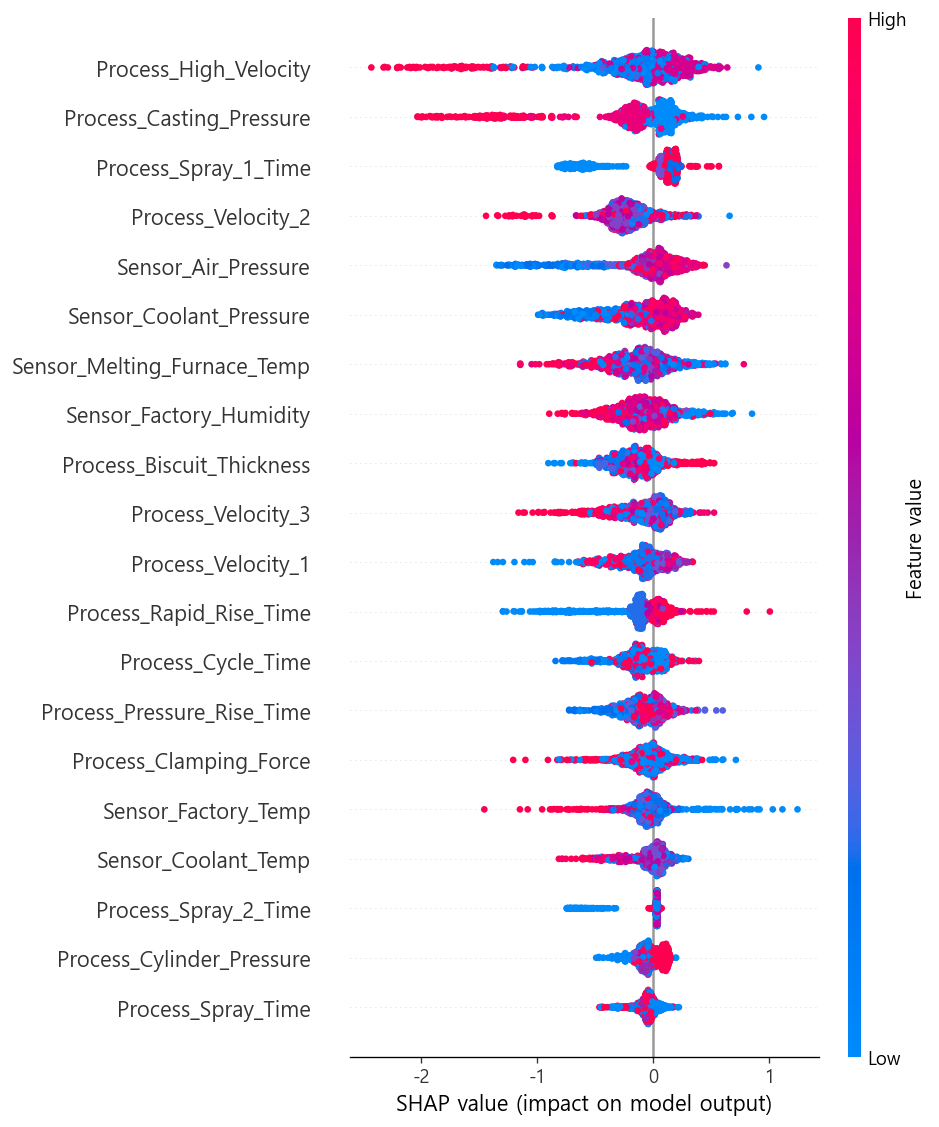

Top2 features: ['Process_High_Velocity', 'Process_Casting_Pressure']


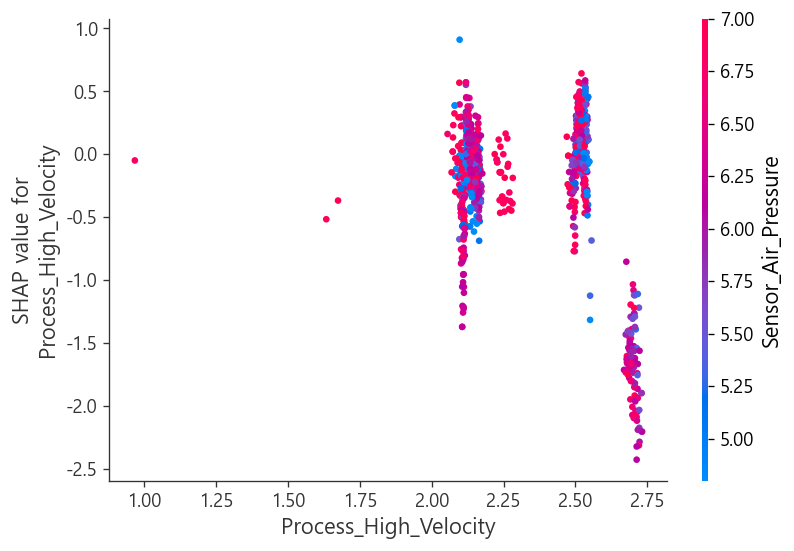

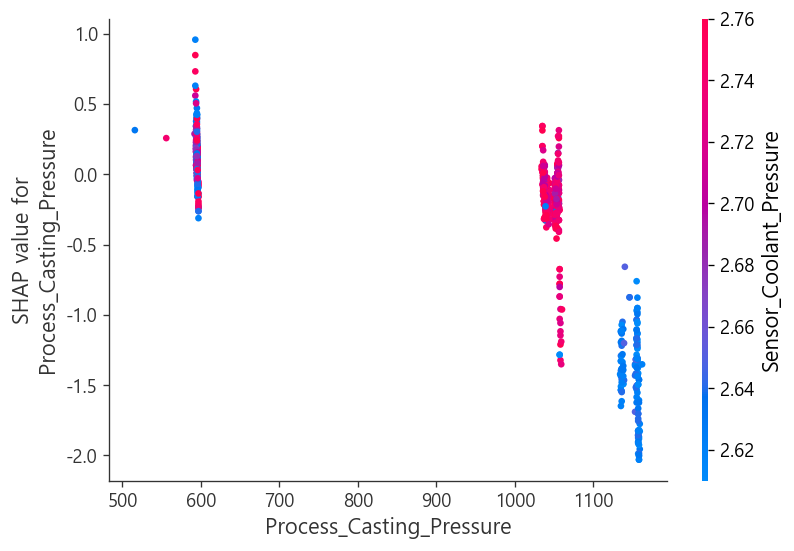

In [24]:
# 이 셀을 실행시키기전에 터미널에서
# pip install --upgrade opencv-python
# 으로 버전 업그레이드하기

import shap
import numpy as np

if 'binary_pipe_final' not in globals():
    raise NameError("binary_pipe_final이 없습니다. STEP1 셀을 먼저 실행하세요.")
if not all(k in globals() for k in ['X_test_']):
    raise NameError("X_test_가 없습니다. STEP1 셀을 먼저 실행하세요.")

xgb_model = binary_pipe_final.named_steps["model"]

# SHAP 계산은 샘플링 권장(속도)
X_shap = X_test_.copy()
if len(X_shap) > 1200:
    X_shap = X_shap.sample(1200, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

print("SHAP shape:", np.array(shap_values).shape)

# 전역 중요도
shap.summary_plot(shap_values, X_shap, show=True)

# 상위 변수 2개 dependence
abs_mean = np.abs(shap_values).mean(axis=0)
top2_idx = np.argsort(abs_mean)[::-1][:2]
top2 = [X_shap.columns[i] for i in top2_idx]
print("Top2 features:", top2)

for f in top2:
    shap.dependence_plot(f, shap_values, X_shap, show=True)


### 7-1. 공정 최적화 리포트 자동 생성

> SHAP 해석 결과를 **현장 의사결정용 요약 리포트(Markdown)**로 자동 생성합니다.

**🧭 이 셀에서 하는 일(무엇/왜/어떻게)**

- **무엇**: 이진 타겟(defect_any) 생성: 양품(0) vs 불량(1)
- **왜**: 실무에서 1차 목표는 ‘불량 여부 조기 경보’인 경우가 많고, 데이터 불균형에도 비교적 강함.
- **어떻게**: 불량 관련 컬럼(여러 유형)을 합산해 1개라도 있으면 1, 없으면 0으로 변환함.


In [26]:

# ============================================================
# STEP 3) 공정 최적화 리포트 자동 생성
#   - Binary 모델(STEP1) 기반 SHAP 해석
#   - 상위 변수별 "위험 구간"을 간단 규칙 형태로 요약
#   - 결과를 Markdown 파일로 저장 + 노트북에서 미리보기
# ============================================================

import numpy as np
import pandas as pd
import shap
from datetime import datetime

# --- STEP1 결과 객체 확인 ---
if 'binary_pipe_final' not in globals() or 'binary_calibrated' not in globals():
    raise NameError("STEP 1을 먼저 실행해서 binary_pipe_final / binary_calibrated 를 생성하세요.")

# feature matrix 확보
if 'X_clipped' in globals():
    X_all = X_clipped.copy()
elif 'X' in globals():
    X_all = X.copy()
else:
    # 보수적 fallback
    drop_cols = [c for c in df.columns if c.startswith("Defects_")] + ['defect_any']
    X_all = df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number]).copy()

# 분석 샘플(속도 고려)
SAMPLE_N = min(1500, len(X_all))
X_sample = X_all.sample(SAMPLE_N, random_state=42)

# --- SHAP 계산 (Pipeline 내 최종 모델만 대상으로) ---
# imblearn Pipeline: 마지막 스텝이 model
xgb_model = binary_pipe_final.named_steps["model"]

explainer = shap.TreeExplainer(xgb_model)
# SHAP 값은 모델 입력 feature 순서가 X_sample.columns와 동일하다고 가정(노트북 내 전처리 흐름 동일)
shap_values = explainer.shap_values(X_sample)

# 전역 중요도 top 10
abs_mean = np.abs(shap_values).mean(axis=0)
imp = pd.Series(abs_mean, index=X_sample.columns).sort_values(ascending=False)
top_feats = imp.head(10).index.tolist()

# --- 위험 구간 요약 함수 ---
def risk_bins_report(feature: str, bins: int = 4) -> pd.DataFrame:
    tmp = pd.DataFrame({
        feature: X_all[feature],
        "proba": binary_calibrated.predict_proba(X_all)[:, 1],
        "y": df["defect_any"].astype(int).values
    }).dropna()

    # qcut이 실패(중복)하면 cut로 fallback
    try:
        tmp["bin"] = pd.qcut(tmp[feature], q=bins, duplicates="drop")
    except Exception:
        tmp["bin"] = pd.cut(tmp[feature], bins=bins)

    out = tmp.groupby("bin").agg(
        n=("y", "size"),
        defect_rate=("y", "mean"),
        avg_pred_proba=("proba", "mean"),
        min_val=(feature, "min"),
        max_val=(feature, "max")
    ).reset_index(drop=True)

    out["defect_rate"] = out["defect_rate"] * 100
    out["avg_pred_proba"] = out["avg_pred_proba"] * 100
    return out.sort_values("avg_pred_proba", ascending=False)

# --- 리포트 작성 ---
lines = []
lines.append("# 🏭 다이캐스팅 공정 최적화 리포트 (Auto)\n")
lines.append(f"- 생성 시각: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
if 'best_threshold' in globals():
    lines.append(f"- 운영 권장 threshold (비용 기반): **{best_threshold:.4f}**  (FN_COST=10, FP_COST=1)\n")

# STEP2 정보
if 'top3_defects' in globals():
    lines.append("\n## ✅ Top 3 불량 유형 (빈도 기준)\n")
    for i, d in enumerate(top3_defects, 1):
        lines.append(f"- Top{i}: `{d}`\n")

lines.append("\n## ✅ Binary 모델 기준 주요 영향 변수 Top 10 (SHAP)\n")
for i, f in enumerate(top_feats, 1):
    lines.append(f"{i}. `{f}`\n")

lines.append("\n## ✅ 공정 변수별 '위험 구간' 요약 (상위 5개 변수)\n")
for f in top_feats[:5]:
    rb = risk_bins_report(f, bins=4).head(4).copy()
    # 최고 위험 구간 1개를 규칙 형태로
    top_row = rb.iloc[0]
    rule = f"- **{f}**: `{top_row['min_val']:.4g} ~ {top_row['max_val']:.4g}` 구간에서 " \
           f"평균 예측 불량확률 **{top_row['avg_pred_proba']:.1f}%**, 실제 불량률 **{top_row['defect_rate']:.1f}%** (n={int(top_row['n'])})\n"
    lines.append(rule)

lines.append("\n## 📌 해석/활용 가이드\n")
lines.append("- 위 '위험 구간'은 **현재 데이터/모델 기준**으로 불량 가능성이 상대적으로 높은 범위를 요약한 것임.\n")
lines.append("- 실제 공정 적용 시에는 (1) 공정 제약조건 (2) 품질/생산성 트레이드오프 (3) 장비/제품 타입별 분리를 함께 고려해 검증할 필요가 있음.\n")
lines.append("- 추후 최적화 방향: 상위 5개 변수에 대해 **현장 기준 허용 범위**와 비교하여, 조정 가능한 변수부터 우선 개선 실험(A/B 또는 DOE)을 설계해야함.\n")

report_md = "".join(lines)

# 파일 저장
out_path = "diecasting_minjun_report.md"
with open(out_path, "w", encoding="utf-8") as f:
    f.write(report_md)

print(f"✅ 리포트 저장 완료: {out_path}")

# 노트북 미리보기
from IPython.display import Markdown, display
display(Markdown(report_md))


✅ 리포트 저장 완료: diecasting_minjun_report.md


# 🏭 다이캐스팅 공정 최적화 리포트 (Auto)
- 생성 시각: 2026-03-03 12:15:28
- 운영 권장 threshold (비용 기반): **0.1390**  (FN_COST=10, FP_COST=1)

## ✅ Top 3 불량 유형 (빈도 기준)
- Top1: `Defects_Short_Shot_1`
- Top2: `Defects_Blow_Hole_1`
- Top3: `Defects_Stain_1`

## ✅ Binary 모델 기준 주요 영향 변수 Top 10 (SHAP)
1. `Process_High_Velocity`
2. `Process_Spray_1_Time`
3. `Process_Casting_Pressure`
4. `Process_Velocity_2`
5. `Sensor_Coolant_Pressure`
6. `Sensor_Melting_Furnace_Temp`
7. `Sensor_Air_Pressure`
8. `Sensor_Factory_Humidity`
9. `Process_Biscuit_Thickness`
10. `Process_Velocity_3`

## ✅ 공정 변수별 '위험 구간' 요약 (상위 5개 변수)
- **Process_High_Velocity**: `2.162 ~ 2.523` 구간에서 평균 예측 불량확률 **30.5%**, 실제 불량률 **30.9%** (n=1921)
- **Process_Spray_1_Time**: `2.4 ~ 2.5` 구간에서 평균 예측 불량확률 **33.2%**, 실제 불량률 **31.6%** (n=136)
- **Process_Casting_Pressure**: `516 ~ 596` 구간에서 평균 예측 불량확률 **28.6%**, 실제 불량률 **28.3%** (n=3150)
- **Process_Velocity_2**: `0.171 ~ 0.182` 구간에서 평균 예측 불량확률 **28.8%**, 실제 불량률 **27.8%** (n=1342)
- **Sensor_Coolant_Pressure**: `2.65 ~ 2.72` 구간에서 평균 예측 불량확률 **25.9%**, 실제 불량률 **26.5%** (n=2160)

## 📌 해석/활용 가이드
- 위 '위험 구간'은 **현재 데이터/모델 기준**으로 불량 가능성이 상대적으로 높은 범위를 요약한 것임.
- 실제 공정 적용 시에는 (1) 공정 제약조건 (2) 품질/생산성 트레이드오프 (3) 장비/제품 타입별 분리를 함께 고려해 검증할 필요가 있음.
- 추후 최적화 방향: 상위 5개 변수에 대해 **현장 기준 허용 범위**와 비교하여, 조정 가능한 변수부터 우선 개선 실험(A/B 또는 DOE)을 설계해야함.
